# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
from google.colab import userdata
from huggingface_hub import login, list_repo_files, hf_hub_download
import pandas as pd
import numpy as np
from scipy import stats
import os

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

files = list_repo_files("FlyRank/internship-warehouse", repo_type="dataset")
march_files = [f for f in files if "fact_content_daily_performance/month=2026-03" in f]
local_paths = [
    hf_hub_download(repo_id="FlyRank/internship-warehouse", filename=f, repo_type="dataset")
    for f in march_files
]
df_raw = pd.concat([pd.read_parquet(p) for p in local_paths], ignore_index=True)
print("Raw rows:", df_raw.shape)

df = df_raw[df_raw['gsc_data_available'] == True].copy()
print(f"GSC-available rows: {len(df)} of {len(df_raw)}")

agg = df.groupby(['client_hash_id', 'content_hash_id']).agg(
    days_with_data=('report_date', 'nunique'),
    total_impressions=('gsc_impressions', 'sum'),
    total_clicks=('gsc_clicks', 'sum'),
    avg_position=('gsc_avg_position', 'mean')
).reset_index()

agg = agg[agg['total_impressions'] > 0].copy()
agg['ctr'] = agg['total_clicks'] / agg['total_impressions']

print("Content-level rows:", agg.shape)
print(agg[['total_impressions', 'total_clicks', 'avg_position', 'ctr']].describe())

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Raw rows: (9841378, 30)
GSC-available rows: 3611061 of 9841378
Content-level rows: (176738, 7)
       total_impressions   total_clicks   avg_position            ctr
count      176738.000000  176738.000000  176738.000000  176738.000000
mean         1587.986675       4.650002      15.999277       0.004594
std          5431.337724      26.722649      17.686260       0.037760
min             1.000000       0.000000       0.000000       0.000000
25%            20.000000       0.000000       5.001970       0.000000
50%           173.000000       0.000000       8.505296       0.000000
75%          1039.000000       2.000000      20.369190       0.002158
max        617124.000000    5668.000000     309.000000       1.000000


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

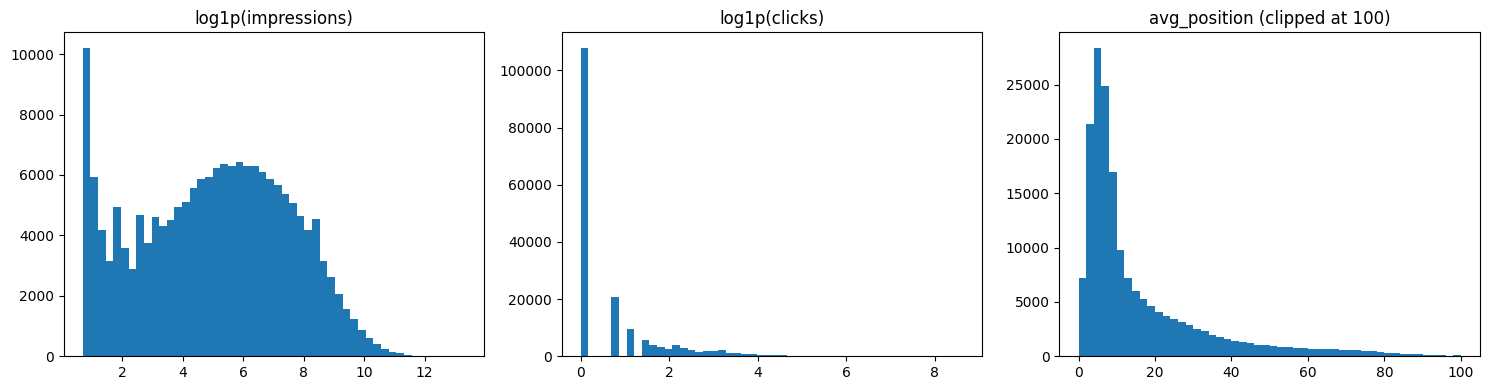

Skew check — mean vs median:
  impressions: mean=1588, median=173
  clicks:      mean=4.65, median=0


In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(np.log1p(agg['total_impressions']), bins=50)
axes[0].set_title('log1p(impressions)')
axes[1].hist(np.log1p(agg['total_clicks']), bins=50)
axes[1].set_title('log1p(clicks)')
axes[2].hist(agg['avg_position'].clip(upper=100), bins=50)
axes[2].set_title('avg_position (clipped at 100)')
plt.tight_layout()
plt.show()

print("Skew check — mean vs median:")
print(f"  impressions: mean={agg['total_impressions'].mean():.0f}, median={agg['total_impressions'].median():.0f}")
print(f"  clicks:      mean={agg['total_clicks'].mean():.2f}, median={agg['total_clicks'].median():.0f}")

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [3]:
rho, pval = stats.spearmanr(agg['total_impressions'], agg['total_clicks'])
print(f"Spearman correlation (impressions vs clicks): rho={rho:.3f}, p={pval:.2e}, n={len(agg)}")

Spearman correlation (impressions vs clicks): rho=0.741, p=0.00e+00, n=176738


In [4]:
signal_pos_imp = agg.groupby('position_bucket', observed=True).agg(
    n=('content_hash_id', 'count'),
    median_impressions=('total_impressions', 'median'),
    mean_impressions=('total_impressions', 'mean')
) if 'position_bucket' in agg.columns else None

# if position_bucket wasn't created yet in this session:
pos_bins = [0, 3, 10, 20, 50, 1000]
pos_labels = ['1-3', '4-10', '11-20', '21-50', '51+']
agg['position_bucket'] = pd.cut(agg['avg_position'], bins=pos_bins, labels=pos_labels)

signal_pos_imp = agg.groupby('position_bucket', observed=True).agg(
    n=('content_hash_id', 'count'),
    median_impressions=('total_impressions', 'median'),
    mean_impressions=('total_impressions', 'mean')
)
print(signal_pos_imp)

                     n  median_impressions  mean_impressions
position_bucket                                             
1-3              16144               249.0       2435.858895
4-10             81988               201.0       1795.227375
11-20            32203               257.0       1081.532497
21-50            33288               177.0       1718.800919
51+              11681                49.0        179.726821


In [5]:
day_bins = [0, 5, 10, 15, 20, 25, 32]
day_labels = ['1-5', '6-10', '11-15', '16-20', '21-25', '26-31']
agg['persistence_bucket'] = pd.cut(agg['days_with_data'], bins=day_bins, labels=day_labels)

signal_persist = agg.groupby('persistence_bucket', observed=True).agg(
    n=('content_hash_id', 'count'),
    clicks_sum=('total_clicks', 'sum'),
    impressions_sum=('total_impressions', 'sum')
)
signal_persist['weighted_ctr'] = signal_persist['clicks_sum'] / signal_persist['impressions_sum']
print(signal_persist[['n', 'weighted_ctr']])

                        n  weighted_ctr
persistence_bucket                     
1-5                 34408      0.005521
6-10                14040      0.004041
11-15               12025      0.004367
16-20               13040      0.003931
21-25               12564      0.003803
26-31               90661      0.002870


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [6]:
bucket_totals = agg.groupby('position_bucket', observed=True).agg(
    n=('content_hash_id', 'count'),
    clicks_sum=('total_clicks', 'sum'),
    impressions_sum=('total_impressions', 'sum')
)
bucket_totals['weighted_ctr'] = bucket_totals['clicks_sum'] / bucket_totals['impressions_sum']
print(bucket_totals[['n', 'weighted_ctr']])

                     n  weighted_ctr
position_bucket                     
1-3              16144      0.004063
4-10             81988      0.003239
11-20            32203      0.003052
21-50            33288      0.001366
51+              11681      0.000392


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.